# Extract NDVI from Analytic Imagery

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import seaborn as sns

from exactextract import exact_extract
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box

sys.path.append("../utils")

import config

### Import buffer geometries

In [20]:
# Import joined inspections and buildings
def import_buffer_geometries(year):
    """
    Function to read in buffer geometry data for a given year and convert to Albers CRS.
    """
    buffer_geometries = os.path.join(
        config.data_dir,
        "buffer_geometries",
        f"buffer_geometries_{year}.geojson",
    )
    buffer_geometries = gpd.read_file(buffer_geometries).to_crs(
        config.albers_crs
    )
    return buffer_geometries


# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
buffer_geometries_dict = {}
for year in range(2019, 2024):
    buffer_geometries_dict[year] = import_buffer_geometries(year)

In [21]:
# Unpack from dictionary
buffer_geometries_2019 = buffer_geometries_dict[2019]
buffer_geometries_2020 = buffer_geometries_dict[2020]
buffer_geometries_2021 = buffer_geometries_dict[2021]
buffer_geometries_2022 = buffer_geometries_dict[2022]
buffer_geometries_2023 = buffer_geometries_dict[2023]

### Import analytic scene and calculate NDVI

In [22]:
# Open image file
image_path = os.path.join(
    config.data_dir, 
    "imagery_for_test", 
    "wildfire_prep_dataset_test2_psscene_analytic_sr_udm2/PSScene/20200318_164124_1020_3B_AnalyticMS_SR.tif"
)
image_file = image_path

In [23]:
# Load red and NIR bands - note all PlanetScope 4-band images have band order BGRN
with rasterio.open(image_file) as src:
    band_red = src.read(3)

with rasterio.open(image_file) as src:
    band_nir = src.read(4)

In [24]:
# Allow division by zero
np.seterr(divide='ignore', invalid='ignore')

# Calculate NDVI
ndvi = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)

In [25]:
# Set spatial characteristics of the output object to mirror the input
kwargs = src.meta
kwargs.update(
    dtype=rasterio.float32,
    count = 1)

# Create the file
with rasterio.open('ndvi.tif', 'w', **kwargs) as dst:
        dst.write_band(1, ndvi.astype(rasterio.float32))

#### Reproject to geometry CRS

In [26]:
# Path to your NDVI file
input_path = 'ndvi.tif'
output_path = 'ndvi_reprojected.tif'

target_crs = config.albers_crs

# Open the source dataset
with rasterio.open(input_path) as src:
    # Calculate the transformation parameters for reprojection
    transform, width, height = calculate_default_transform(
        src.crs, target_crs, src.width, src.height, *src.bounds)
    
    # Update the metadata for the output file
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': target_crs,
        'transform': transform,
        'width': width,
        'height': height
    })
    
    # Create the output file with the updated metadata
    with rasterio.open(output_path, 'w', **kwargs) as dst:
        # Reproject each band
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest)

In [27]:
# First, open the NDVI raster to get its extent
with rasterio.open('ndvi.tif') as src:
    # Get the bounds of the raster
    raster_bounds = src.bounds
    # Create a polygon from the bounds
    raster_geometry = box(raster_bounds.left, raster_bounds.bottom, 
                          raster_bounds.right, raster_bounds.top)
    # Create a GeoDataFrame from the raster extent
    raster_extent = gpd.GeoDataFrame({'geometry': [raster_geometry]}, crs=src.crs)
    
    # Check if we need to reproject the extent
    if buffer_geometries_2019.crs != src.crs:
        raster_extent = raster_extent.to_crs(buffer_geometries_2019.crs)


In [28]:
# Filter buffer geometries to only those that intersect with the raster extent
intersecting_buffers = buffer_geometries_2019[
    buffer_geometries_2019.intersects(raster_extent.iloc[0].geometry)
]

print(f"Found {len(intersecting_buffers)} geometries that intersect with the NDVI raster")

Found 241 geometries that intersect with the NDVI raster


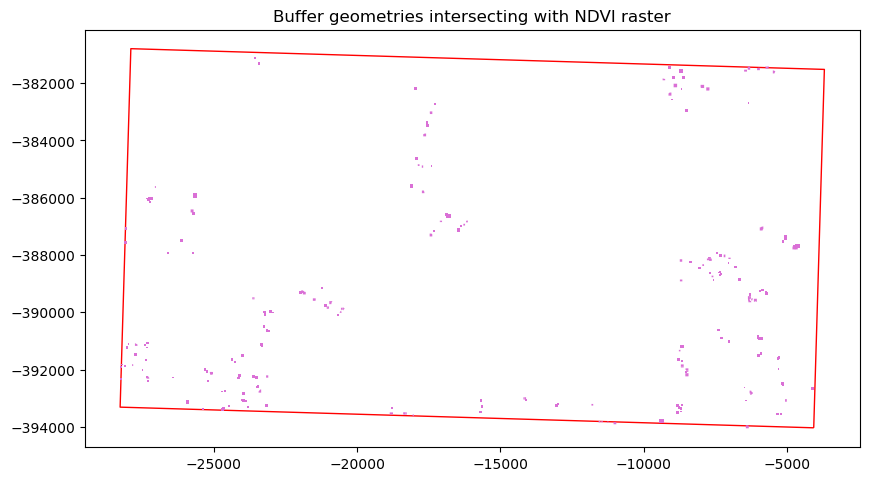

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
raster_extent.plot(ax=ax, color='none', edgecolor='red', linewidth=1)
intersecting_buffers.plot(ax=ax, color='orchid')
plt.title("Training location geometries intersecting with NDVI raster")
plt.show()

In [30]:
# Extract NDVI values only for the intersecting geometries
# First ensure the CRS match
if intersecting_buffers.crs != src.crs:
    intersecting_buffers = intersecting_buffers.to_crs(src.crs)

# Use exactextract to calculate statistics for each geometry
ndvi_stats = exact_extract(
    'ndvi.tif',
    intersecting_buffers,
    ['mean', 'min', 'max'],
    include_cols=['fulcrum_id'], 
    output="pandas",
)
ndvi_stats

,fulcrum_id,mean,min,max
0,ab908c18-81ea-41b3-9660-a1164b83cbfc,0.573630,0.290996,0.708489
1,dd382f97-13d8-40ed-b60d-334db1837d41,0.603233,0.095989,0.760937
2,4dc4cc0d-e60a-4802-a6bf-3d82b9627a95,0.521713,0.118020,0.659507
3,13dca165-8a39-4aa9-b517-d25310a0813b,0.570567,0.136768,0.772065
4,1e569cfd-fba3-43f7-9656-a74da7e13eb9,0.613597,0.204697,0.790365
...,...,...,...,...
236,6b17c356-55d8-4b8f-b9d1-5e5fa7c120d4,NaN,NaN,NaN
237,14f60df6-c443-4920-b08d-3c4dde200ecc,NaN,NaN,NaN
238,f0e17cc7-4185-4dab-a9e6-f825aa792cad,0.520909,0.210332,0.707581
239,3a6c6042-7afc-4e08-b8bf-02f239c90d63,0.627831,0.352922,0.736126


/tmp/ipykernel_2533599/4036650618.py:53: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mean_patch = mpatches.Patch(color='none', edgecolor='white', label='Property Buffer Zone')


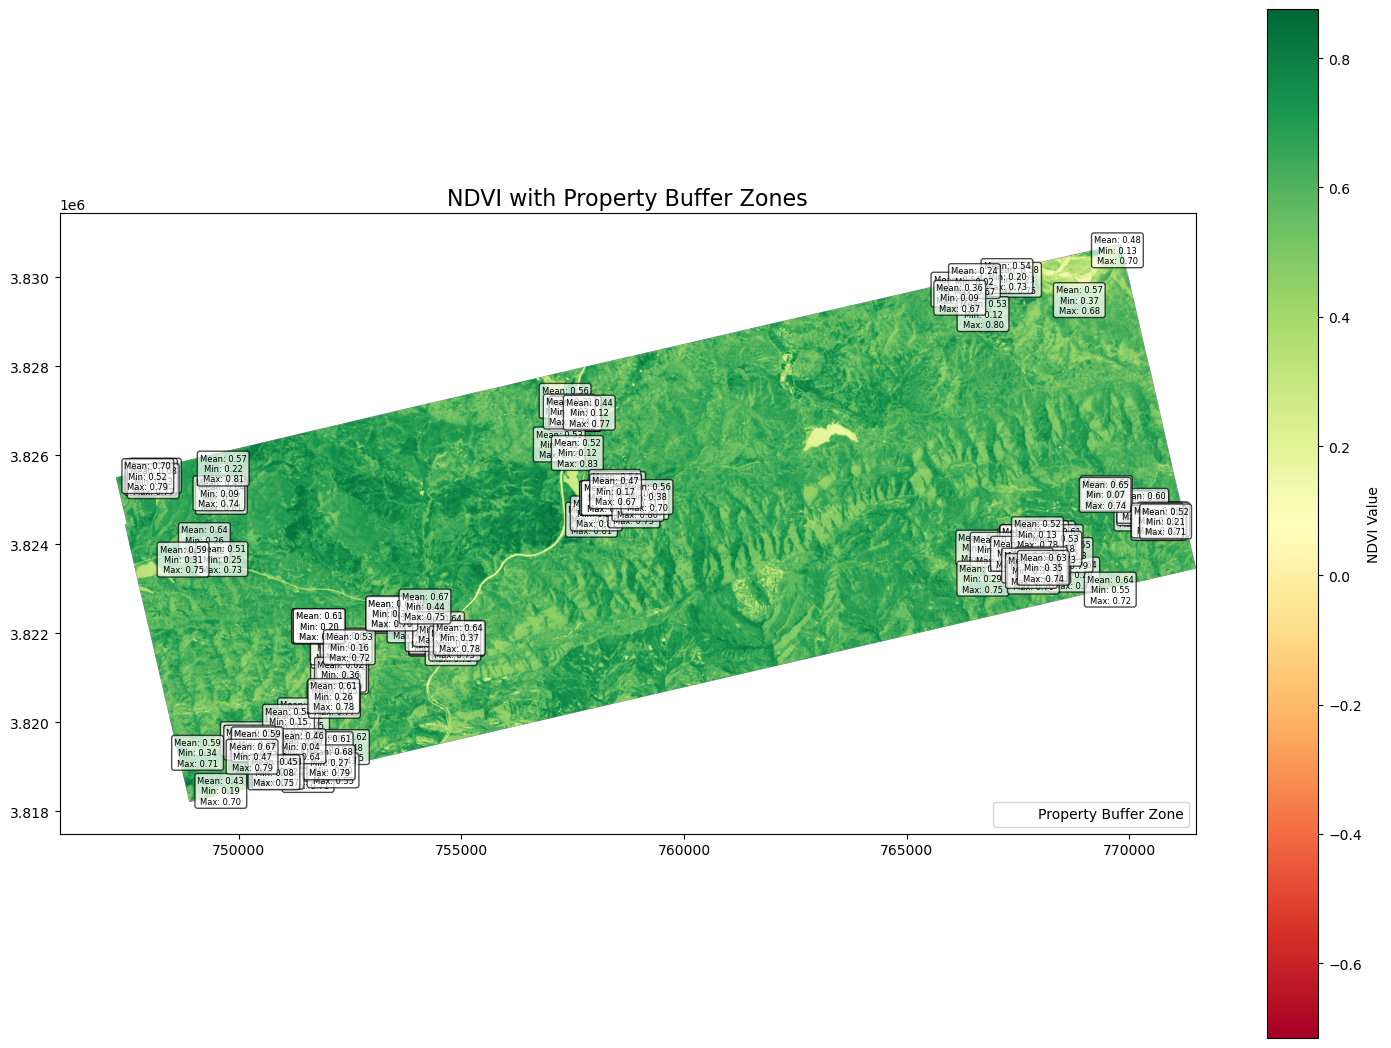

In [31]:
# Open the NDVI raster
with rasterio.open('ndvi.tif') as src:
    ndvi = src.read(1)
    transform = src.transform
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Define a colormap for NDVI (false color)
    ndvi_cmap = plt.cm.RdYlGn  # Red-Yellow-Green colormap
    
    # Plot the NDVI raster with matplotlib's imshow
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    im = ax.imshow(ndvi, cmap=ndvi_cmap, extent=extent)
    ax.set_title('NDVI with Property Buffer Zones', fontsize=16)
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('NDVI Value')
    
    # Import buffer geometries and reproject to match the raster CRS
    buffer_geometries = intersecting_buffers.to_crs(src.crs)
    
    # Merge with the NDVI stats
    buffer_with_ndvi = buffer_geometries.copy()
    buffer_with_ndvi = buffer_with_ndvi.merge(ndvi_stats, on='fulcrum_id')
    
    # Plot the geometries with transparent fill but visible boundaries
    buffer_with_ndvi.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=1, alpha=0.8)
    
    # Add text labels for NDVI statistics on each geometry
    for idx, row in buffer_with_ndvi.iterrows():
        # Skip if we have NaN values
        if np.isnan(row['mean']):
            continue
            
        # Get centroid for label placement
        centroid = row['geometry'].centroid
        label_text = f"Mean: {row['mean']:.2f}\nMin: {row['min']:.2f}\nMax: {row['max']:.2f}"
        
        # Add text with a white background for readability
        ax.annotate(
            text=label_text,
            xy=(centroid.x, centroid.y),
            ha='center',
            va='center',
            fontsize=6,
            color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7)
        )
    
    # Add legend
    mean_patch = mpatches.Patch(color='none', edgecolor='white', label='Property Buffer Zone')
    plt.legend(handles=[mean_patch], loc='lower right')
    
    # Set layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('ndvi_with_property_stats.png', dpi=300, bbox_inches='tight')
    
    # Show the plot
    plt.show()

/tmp/ipykernel_2533599/805524264.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mean_patch = mpatches.Patch(color='none', edgecolor='black', label='Property Buffer Zone')


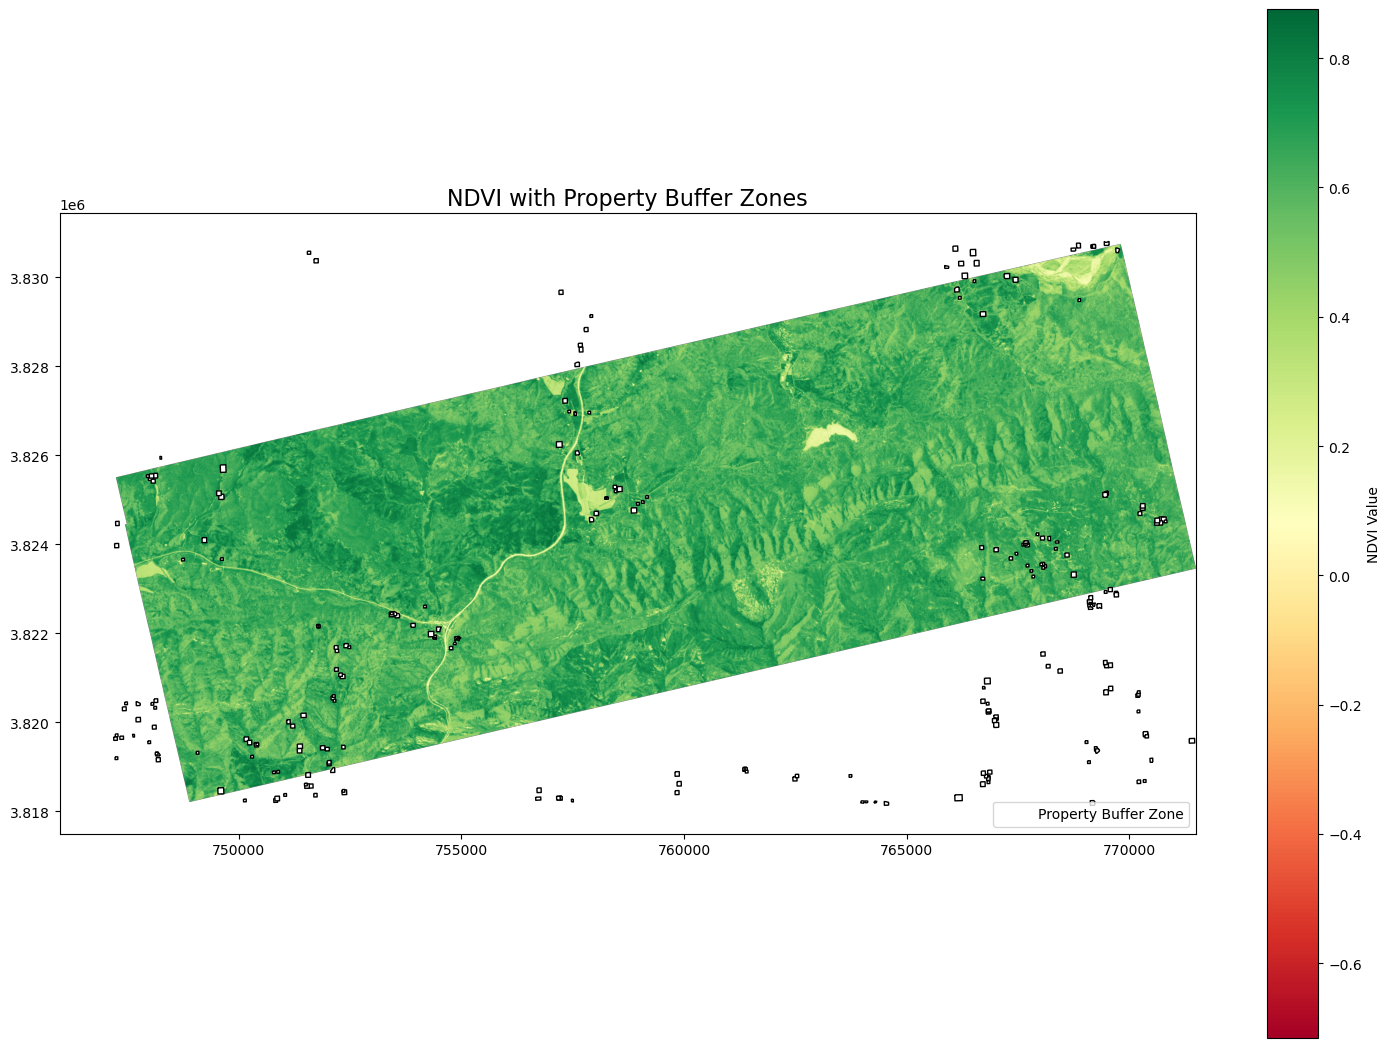

In [32]:
# Open the NDVI raster
with rasterio.open('ndvi.tif') as src:
    ndvi = src.read(1)
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Define a colormap for NDVI (false color)
    ndvi_cmap = plt.cm.RdYlGn  # Red-Yellow-Green colormap
    
    # Plot the NDVI raster with matplotlib's imshow
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    im = ax.imshow(ndvi, cmap=ndvi_cmap, extent=extent)
    ax.set_title('NDVI with Property Buffer Zones', fontsize=16)
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('NDVI Value')
    
    # Import your buffer geometries and reproject to match the raster CRS
    buffer_geometries = intersecting_buffers.to_crs(src.crs)
    
    # Merge with the NDVI stats
    buffer_with_ndvi = buffer_geometries.copy()
    buffer_with_ndvi = buffer_with_ndvi.merge(ndvi_stats, on='fulcrum_id')
    
    # Plot the geometries with transparent fill but visible boundaries
    buffer_with_ndvi.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1)
    
    # Add legend
    mean_patch = mpatches.Patch(color='none', edgecolor='black', label='Property Buffer Zone')
    plt.legend(handles=[mean_patch], loc='lower right')
    
    # Set layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()

## Create a dataframe with NDVI, status, and inspection ID

In [33]:
# Merge NDVI statistics with buffer geometries
ndvi_stats_joined = ndvi_stats.merge(
    buffer_geometries_2019[['fulcrum_id', 'status', 'Date', 'geometry']],
    on='fulcrum_id',
    how='left'
)

# Rename columns for clarity
ndvi_stats_joined = ndvi_stats_joined.rename(columns={'Date': 'inspection_date',
                                                      'mean': 'mean_ndvi',
                                                      'min': 'min_ndvi',
                                                      'max': 'max_ndvi'})
ndvi_stats_joined

,fulcrum_id,mean_ndvi,min_ndvi,max_ndvi,status,inspection_date,geometry
0,ab908c18-81ea-41b3-9660-a1164b83cbfc,0.573630,0.290996,0.708489,Compliant,2019-06-17,"POLYGON ((-24006.101 -392794.393, -23901.051 -..."
1,dd382f97-13d8-40ed-b60d-334db1837d41,0.603233,0.095989,0.760937,Compliant,2019-06-17,"POLYGON ((-23289.769 -390457.122, -23204.711 -..."
2,4dc4cc0d-e60a-4802-a6bf-3d82b9627a95,0.521713,0.118020,0.659507,Compliant,2019-06-17,"POLYGON ((-23262.543 -390042.937, -23185.27 -3..."
3,13dca165-8a39-4aa9-b517-d25310a0813b,0.570567,0.136768,0.772065,Compliant,2019-06-17,"POLYGON ((-23282.433 -389959.897, -23196.448 -..."
4,1e569cfd-fba3-43f7-9656-a74da7e13eb9,0.613597,0.204697,0.790365,Compliant,2019-06-17,"POLYGON ((-23169.232 -390610.296, -23060.634 -..."
...,...,...,...,...,...,...,...
259,6b17c356-55d8-4b8f-b9d1-5e5fa7c120d4,NaN,NaN,NaN,Compliant,2019-06-14,"POLYGON ((-11280.37 -393853.466, -11265.351 -3..."
260,14f60df6-c443-4920-b08d-3c4dde200ecc,NaN,NaN,NaN,Compliant,2019-06-14,"POLYGON ((-11252.263 -393847.677, -11239.96 -3..."
261,f0e17cc7-4185-4dab-a9e6-f825aa792cad,0.520909,0.210332,0.707581,Compliant,2019-09-11,"POLYGON ((-4580.495 -387697.443, -4519.535 -38..."
262,3a6c6042-7afc-4e08-b8bf-02f239c90d63,0.627831,0.352922,0.736126,Compliant,2019-09-12,"POLYGON ((-7355.823 -388656.616, -7294.863 -38..."
